# Model Comparison

## Machine Learning-Based Network Intrusion Detection System

### 1. Introduction

The objective of this notebook is to compare multiple machine learning classification algorithms for the network intrusion detection problem using the CIC-IDS2017 dataset.

The previous stages of the project completed data exploration, preprocessing, feature selection, baseline model development, and hyperparameter tuning. As a result, a final set of **12 selected features** is available for model development.

This notebook uses the final selected training and testing datasets produced during the feature-selection stage. All models will therefore be trained and evaluated using the same input features and the same target labels to ensure a fair comparison.

### 2. Input Data

The following processed datasets will be used:

- `X_train_selected.csv` — selected training features
- `X_test_selected.csv` — selected testing features
- `y_train_selected.csv` — training target labels
- `y_test_selected.csv` — testing target labels

The selected feature set contains the following network traffic characteristics:

1. Destination Port
2. Flow Duration
3. Total Fwd Packets
4. Total Length of Fwd Packets
5. Total Length of Bwd Packets
6. Fwd Packet Length Mean
7. Bwd Packet Length Min
8. Bwd Packets/s
9. PSH Flag Count
10. Init_Win_bytes_forward
11. Init_Win_bytes_backward
12. min_seg_size_forward

### 3. Models for Comparison

The following classification algorithms will be considered:

- Logistic Regression
- Decision Tree
- Random Forest
- Gradient Boosting
- XGBoost, if the package is available in the current Python environment

These algorithms provide a comparison between linear, tree-based, ensemble, and boosting approaches.

The existing Random Forest models from the previous stages will also be incorporated where appropriate so that the baseline and tuned Random Forest performance can be compared with the other algorithms.

### 4. Evaluation Metrics

Each model will be evaluated using:

- Accuracy
- Precision
- Recall
- F1-score
- Macro F1-score
- Training time
- Prediction time

Because the CIC-IDS2017 dataset contains multiple traffic classes with substantial class imbalance, **Macro F1-score** will receive particular attention.

Macro F1 calculates the F1-score independently for each class and then gives equal importance to every class. Therefore, it provides a more informative view of performance across minority attack classes than accuracy alone.

### 5. Experimental Methodology

The comparison will follow a consistent experimental procedure:

1. Load the final selected training and testing datasets.
2. Verify the feature and target dimensions.
3. Verify that the training and testing feature sets are consistent.
4. Train each candidate model using only the training data.
5. Measure the training time for each model.
6. Generate predictions using the unseen testing data.
7. Measure prediction time.
8. Calculate the evaluation metrics.
9. Store the results in a structured comparison table.
10. Identify the strongest model based primarily on Macro F1-score while also considering the other performance metrics and computational cost.

The test dataset will be used only for model evaluation. It will not be used for model training, feature selection, or hyperparameter optimization.

### 6. Expected Outcome

The final comparison will help determine which machine learning approach provides the most suitable balance between classification performance and computational efficiency for the network intrusion detection task.

The results obtained in this notebook will be used as the basis for selecting the final model for detailed evaluation in the subsequent stage of the project.

In [4]:
import pandas as pd
import numpy as np
import time

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

## 📂 Load the Final Selected Dataset

The final feature-selected datasets generated in **Notebook 03 — Feature Selection** will be used for model comparison.

The datasets contain:

* **894,944 training samples**
* **223,737 testing samples**
* **12 selected network traffic features**
* **4 target classes**

Using these finalized datasets ensures that every machine learning model is evaluated on the **same features and same train/test split**.

The test dataset will remain completely unseen during model training.


In [5]:
# Load the final selected training and testing datasets

X_train = pd.read_csv("../data/processed/X_train_selected.csv")
X_test = pd.read_csv("../data/processed/X_test_selected.csv")

y_train = pd.read_csv("../data/processed/y_train_selected.csv")
y_test = pd.read_csv("../data/processed/y_test_selected.csv")

# Display confirmation
print("Datasets loaded successfully.")

Datasets loaded successfully.


## 📐 Dataset Dimensions

Before training the models, the dimensions of the selected training and testing datasets are verified.

The expected structure is:

* **Training features:** 894,944 samples × 12 features
* **Testing features:** 223,737 samples × 12 features
* **Training target:** 894,944 samples
* **Testing target:** 223,737 samples

These dimensions confirm that the final **12 selected features** are being used consistently for model comparison.


In [6]:
print("Dataset Shapes")
print("-" * 40)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape : {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape : {y_test.shape}")

Dataset Shapes
----------------------------------------
X_train shape: (894944, 12)
X_test shape : (223737, 12)
y_train shape: (894944, 1)
y_test shape : (223737, 1)


## 🔍 Feature and Target Consistency Check

Before training the classification models, the feature and target datasets are checked for consistency.

The following conditions must be satisfied:

1. Training feature rows must match training target rows.
2. Testing feature rows must match testing target rows.
3. The number of features must be **12**.
4. Training and testing datasets must contain the same feature columns in the same order.
5. The target column must be consistent across training and testing datasets.

These checks help prevent dimensional mismatches and ensure that all models receive the same input structure during comparison.


In [7]:
# Feature and target consistency checks

target_column = y_train.columns[0]

print("Feature and Target Consistency Check")
print("-" * 45)

print(f"Feature consistency: {list(X_train.columns) == list(X_test.columns)}")
print(f"Training rows match target: {len(X_train) == len(y_train)}")
print(f"Testing rows match target: {len(X_test) == len(y_test)}")
print(f"Number of features: {X_train.shape[1]}")
print(f"Target column: {target_column}")
print(f"Target consistency: {list(y_train.columns) == list(y_test.columns)}")

Feature and Target Consistency Check
---------------------------------------------
Feature consistency: True
Training rows match target: True
Testing rows match target: True
Number of features: 12
Target column: Target_Encoded
Target consistency: True


## 📊 Target Class Distribution

The target class distribution is examined before training the models to understand the level of class imbalance in the dataset.

The CIC-IDS2017 dataset contains four encoded target classes:

* **Class 0**
* **Class 1**
* **Class 2**
* **Class 3**

The distribution is important because the dataset is highly imbalanced, with Class 0 representing the majority of observations and Class 1 representing a much smaller proportion.

Therefore, **Macro F1-score** will be considered an important evaluation metric during model comparison because it evaluates performance across all classes more equally.


In [8]:
# Target class distribution

train_distribution = y_train[target_column].value_counts().sort_index()
test_distribution = y_test[target_column].value_counts().sort_index()

train_percentage = (
    y_train[target_column]
    .value_counts(normalize=True)
    .sort_index()
    .mul(100)
)

test_percentage = (
    y_test[target_column]
    .value_counts(normalize=True)
    .sort_index()
    .mul(100)
)

target_distribution = pd.DataFrame({
    "Train Count": train_distribution,
    "Train Percentage": train_percentage.round(2),
    "Test Count": test_distribution,
    "Test Percentage": test_percentage.round(2)
})

print("Target Class Distribution")
print("-" * 60)

display(target_distribution)

Target Class Distribution
------------------------------------------------------------


,Train Count,Train Percentage,Test Count,Test Percentage
Target_Encoded,,,,
0,718314,80.26,179579,80.26
1,1562,0.17,391,0.17
2,102413,11.44,25603,11.44
3,72655,8.12,18164,8.12


## 🤖 Machine Learning Models for Comparison

Four classification algorithms will be trained using the same final 12-feature dataset:

1. **Logistic Regression** — A linear classification model that provides a simple baseline for comparison.
2. **Decision Tree** — A tree-based model capable of learning nonlinear decision boundaries.
3. **Random Forest** — An ensemble of decision trees that was used as the baseline and tuned model in the previous notebooks.
4. **Gradient Boosting** — An ensemble technique that builds models sequentially to improve predictive performance.

All models will be trained using the training dataset only and evaluated on the held-out testing dataset.

The comparison will help determine which algorithm provides the best balance of predictive performance and computational efficiency for the network intrusion detection task.


In [9]:
# Define machine learning models for comparison

models = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ),
    
    "Decision Tree": DecisionTreeClassifier(
        class_weight="balanced",
        random_state=42
    ),
    
    "Random Forest": RandomForestClassifier(
        n_estimators=100,
        class_weight="balanced_subsample",
        n_jobs=-1,
        random_state=42
    ),
    
    "Gradient Boosting": GradientBoostingClassifier(
        n_estimators=100,
        random_state=42
    )
}

print("Models defined successfully:")
for model_name in models:
    print(f"- {model_name}")

Models defined successfully:
- Logistic Regression
- Decision Tree
- Random Forest
- Gradient Boosting


## 🔄 Model Training and Evaluation

Each model will be trained using the same training dataset and evaluated on the same held-out test dataset.

For every model, the following metrics will be recorded:

* Accuracy
* Weighted Precision
* Weighted Recall
* Weighted F1-score
* Macro F1-score
* Training Time
* Prediction Time

**Macro F1-score** will receive particular attention because the dataset is highly imbalanced and the minority classes are important for intrusion detection.


In [10]:
# Train and evaluate all models

results = []
trained_models = {}
predictions = {}

for model_name, model in models.items():
    print(f"\nTraining {model_name}...")
    
    # Training
    start_train = time.time()
    model.fit(X_train, y_train[target_column])
    train_time = time.time() - start_train
    
    # Prediction
    start_predict = time.time()
    y_pred = model.predict(X_test)
    predict_time = time.time() - start_predict
    
    # Metrics
    accuracy = accuracy_score(y_test[target_column], y_pred)
    precision = precision_score(
        y_test[target_column],
        y_pred,
        average="weighted",
        zero_division=0
    )
    recall = recall_score(
        y_test[target_column],
        y_pred,
        average="weighted",
        zero_division=0
    )
    f1 = f1_score(
        y_test[target_column],
        y_pred,
        average="weighted",
        zero_division=0
    )
    macro_f1 = f1_score(
        y_test[target_column],
        y_pred,
        average="macro",
        zero_division=0
    )
    
    results.append({
        "Model": model_name,
        "Accuracy": accuracy,
        "Weighted Precision": precision,
        "Weighted Recall": recall,
        "Weighted F1": f1,
        "Macro F1": macro_f1,
        "Training Time (s)": train_time,
        "Prediction Time (s)": predict_time
    })
    
    trained_models[model_name] = model
    predictions[model_name] = y_pred
    
    print(f"Training time   : {train_time:.2f} seconds")
    print(f"Prediction time  : {predict_time:.2f} seconds")
    print(f"Accuracy         : {accuracy:.6f}")
    print(f"Weighted F1      : {f1:.6f}")
    print(f"Macro F1         : {macro_f1:.6f}")

results_df = pd.DataFrame(results)

print("\nAll models trained and evaluated successfully.")


Training Logistic Regression...
Training time   : 16.57 seconds
Prediction time  : 0.03 seconds
Accuracy         : 0.959600
Weighted F1      : 0.975757
Macro F1         : 0.760096

Training Decision Tree...
Training time   : 7.16 seconds
Prediction time  : 0.04 seconds
Accuracy         : 0.999169
Weighted F1      : 0.999172
Macro F1         : 0.947471

Training Random Forest...
Training time   : 34.84 seconds
Prediction time  : 0.31 seconds
Accuracy         : 0.999057
Weighted F1      : 0.999122
Macro F1         : 0.946513

Training Gradient Boosting...
Training time   : 558.28 seconds
Prediction time  : 1.46 seconds
Accuracy         : 0.999280
Weighted F1      : 0.999222
Macro F1         : 0.947336

All models trained and evaluated successfully.


## 📊 Model Comparison Results

The performance of all four machine learning models is summarized using the evaluation metrics calculated on the held-out test dataset.

The comparison focuses particularly on **Macro F1-score**, since the network intrusion dataset contains significant class imbalance. Training and prediction times are also considered to evaluate computational efficiency.


In [11]:
# Display model comparison results

comparison_df = results_df.copy()

comparison_df = comparison_df.sort_values(
    by="Macro F1",
    ascending=False
).reset_index(drop=True)

print("Model Comparison Results")
print("-" * 80)

display(comparison_df.round(6))

Model Comparison Results
--------------------------------------------------------------------------------


,Model,Accuracy,Weighted Precision,Weighted Recall,Weighted F1,Macro F1,Training Time (s),Prediction Time (s)
0,Decision Tree,0.999169,0.999175,0.999169,0.999172,0.947471,7.156622,0.035873
1,Gradient Boosting,0.999280,0.999266,0.999280,0.999222,0.947336,558.276338,1.464934
2,Random Forest,0.999057,0.999252,0.999057,0.999122,0.946513,34.842868,0.310575
3,Logistic Regression,0.959600,0.994467,0.959600,0.975757,0.760096,16.567240,0.026590


## 🏆 Macro F1-score Comparison

The Macro F1-score provides an equal-weighted evaluation across all target classes, making it an important metric for this highly imbalanced intrusion detection dataset.

The models will be compared based on their Macro F1-score to identify the model that provides the strongest overall performance across all classes.


In [12]:
# Compare models based on Macro F1-score

macro_f1_comparison = comparison_df[
    ["Model", "Macro F1"]
].copy()

macro_f1_comparison = macro_f1_comparison.sort_values(
    by="Macro F1",
    ascending=False
).reset_index(drop=True)

print("Models Ranked by Macro F1-score")
print("-" * 50)

display(macro_f1_comparison.round(6))

best_macro_f1_model = macro_f1_comparison.iloc[0]["Model"]
best_macro_f1_score = macro_f1_comparison.iloc[0]["Macro F1"]

print(f"\nBest model by Macro F1-score: {best_macro_f1_model}")
print(f"Macro F1-score: {best_macro_f1_score:.6f}")

Models Ranked by Macro F1-score
--------------------------------------------------


,Model,Macro F1
0,Decision Tree,0.947471
1,Gradient Boosting,0.947336
2,Random Forest,0.946513
3,Logistic Regression,0.760096



Best model by Macro F1-score: Decision Tree
Macro F1-score: 0.947471


## 📈 Overall Model Performance Comparison

The models are compared using Accuracy, Weighted Precision, Weighted Recall, Weighted F1-score, and Macro F1-score.

Macro F1 is given greater importance because it evaluates all classes equally, while the weighted metrics are influenced more strongly by the majority class.


In [13]:
# Display predictive performance metrics for all models

performance_metrics = comparison_df[
    [
        "Model",
        "Accuracy",
        "Weighted Precision",
        "Weighted Recall",
        "Weighted F1",
        "Macro F1"
    ]
].copy()

print("Predictive Performance Comparison")
print("-" * 80)

display(performance_metrics.round(6))

Predictive Performance Comparison
--------------------------------------------------------------------------------


,Model,Accuracy,Weighted Precision,Weighted Recall,Weighted F1,Macro F1
0,Decision Tree,0.999169,0.999175,0.999169,0.999172,0.947471
1,Gradient Boosting,0.999280,0.999266,0.999280,0.999222,0.947336
2,Random Forest,0.999057,0.999252,0.999057,0.999122,0.946513
3,Logistic Regression,0.959600,0.994467,0.959600,0.975757,0.760096


## ⏱️ Training Time Comparison

Training time is compared to evaluate the computational efficiency of the four machine learning models.

A model with similar predictive performance but substantially lower training time can be preferable for practical deployment, especially when frequent model retraining may be required.


In [14]:
# Compare model training and prediction times

time_comparison = comparison_df[
    ["Model", "Training Time (s)", "Prediction Time (s)"]
].copy()

time_comparison = time_comparison.sort_values(
    by="Training Time (s)",
    ascending=True
).reset_index(drop=True)

print("Computational Efficiency Comparison")
print("-" * 70)

display(time_comparison.round(3))

Computational Efficiency Comparison
----------------------------------------------------------------------


,Model,Training Time (s),Prediction Time (s)
0,Decision Tree,7.157,0.036
1,Logistic Regression,16.567,0.027
2,Random Forest,34.843,0.311
3,Gradient Boosting,558.276,1.465


## 📊 Model Performance Visualization

A visual comparison is created to make the differences in model performance easier to interpret.

The Macro F1-score is emphasized because it provides a balanced view of performance across the highly imbalanced target classes.


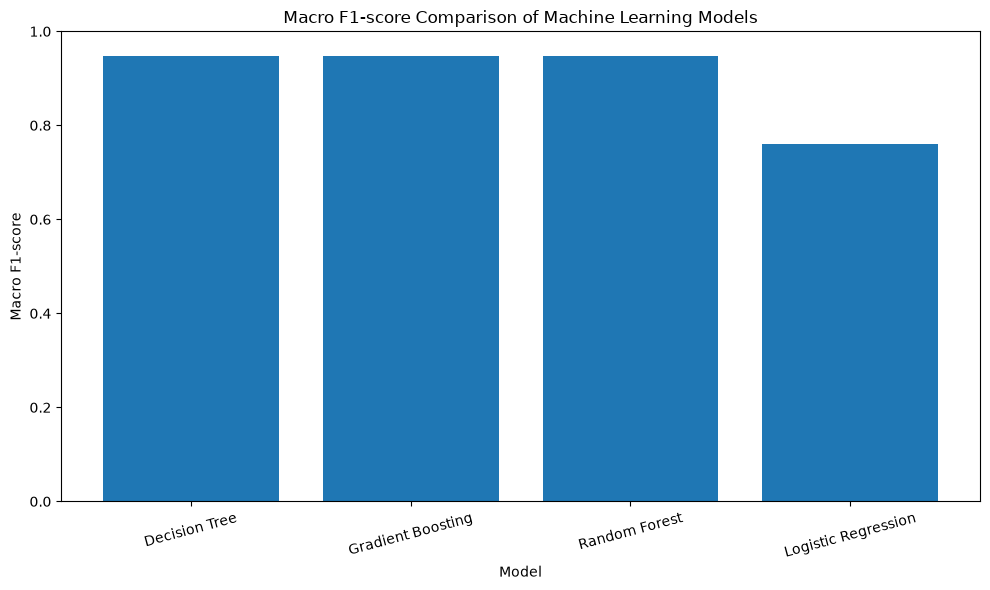

In [15]:
# Visualize Macro F1-score for all models

plt.figure(figsize=(10, 6))

plt.bar(
    comparison_df["Model"],
    comparison_df["Macro F1"]
)

plt.xlabel("Model")
plt.ylabel("Macro F1-score")
plt.title("Macro F1-score Comparison of Machine Learning Models")
plt.ylim(0, 1)

plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

## ⏱️ Training Time Visualization

The training time of each model is visualized to compare computational efficiency.

This comparison helps identify models that provide strong predictive performance while requiring less computational time for training.


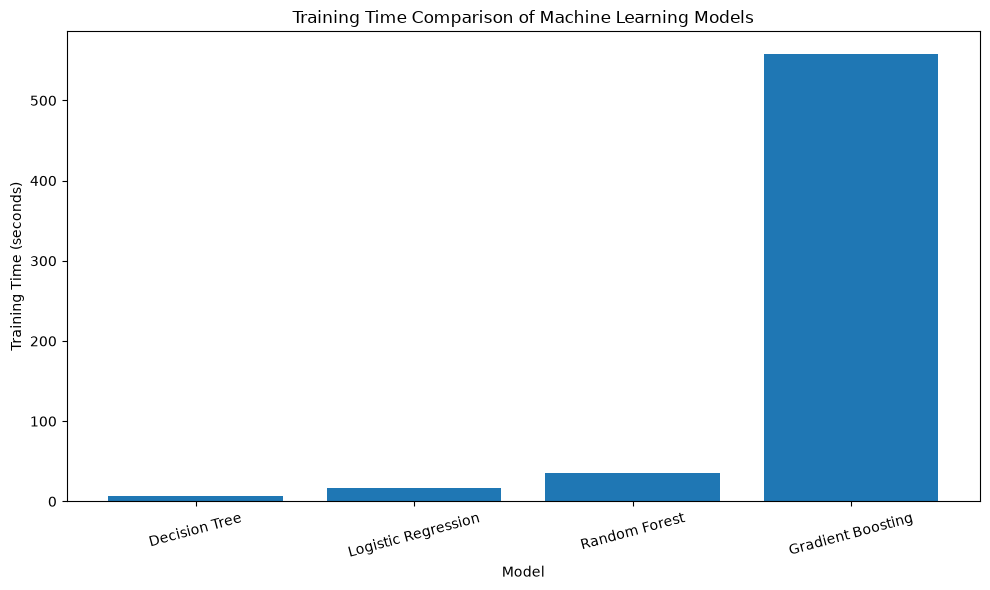

In [16]:
# Visualize training time for all models

plt.figure(figsize=(10, 6))

plt.bar(
    time_comparison["Model"],
    time_comparison["Training Time (s)"]
)

plt.xlabel("Model")
plt.ylabel("Training Time (seconds)")
plt.title("Training Time Comparison of Machine Learning Models")

plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

## ⚡ Prediction Time Comparison

Prediction time is compared to evaluate how efficiently each trained model can classify unseen network traffic.

Lower prediction time indicates faster inference, which can be beneficial for real-time or near-real-time intrusion detection applications.


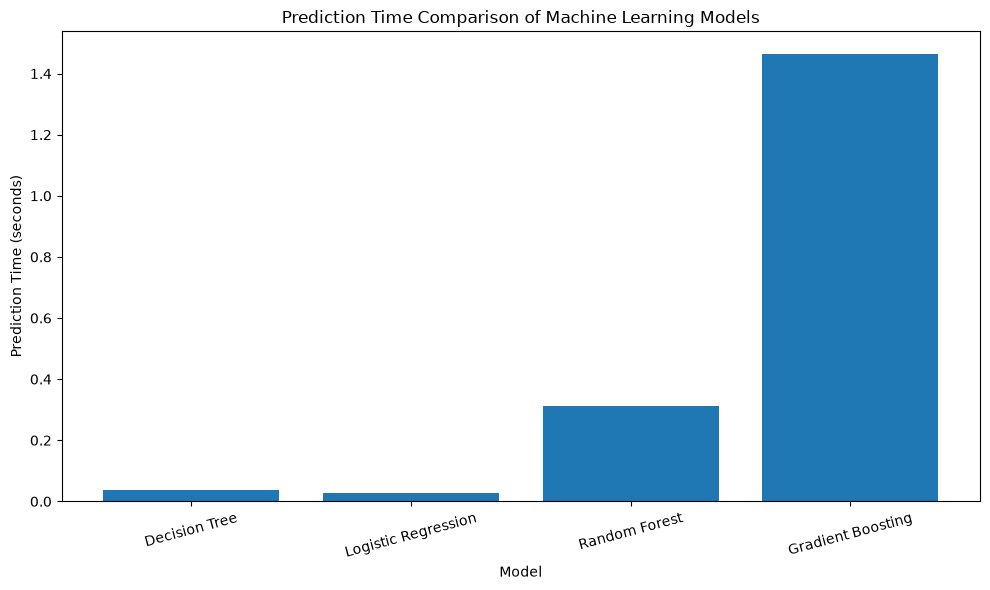

In [17]:
# Visualize prediction time for all models

plt.figure(figsize=(10, 6))

plt.bar(
    time_comparison["Model"],
    time_comparison["Prediction Time (s)"]
)

plt.xlabel("Model")
plt.ylabel("Prediction Time (seconds)")
plt.title("Prediction Time Comparison of Machine Learning Models")

plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

## 🏆 Final Model Selection

The final model is selected by considering predictive performance and computational efficiency together.

Since the dataset is highly imbalanced, **Macro F1-score** is the primary metric. Accuracy and weighted F1-score are also considered, while training and prediction time are used to assess computational efficiency.

A model with a strong Macro F1-score and substantially lower computational cost provides a practical balance between detection performance and efficiency.
v

In [18]:
# Identify the best-performing models using different criteria

best_macro_f1 = comparison_df.loc[
    comparison_df["Macro F1"].idxmax()
]

best_accuracy = comparison_df.loc[
    comparison_df["Accuracy"].idxmax()
]

best_training_time = comparison_df.loc[
    comparison_df["Training Time (s)"].idxmin()
]

best_prediction_time = comparison_df.loc[
    comparison_df["Prediction Time (s)"].idxmin()
]

print("Model Selection Summary")
print("-" * 60)

print(
    f"Best Macro F1       : {best_macro_f1['Model']} "
    f"({best_macro_f1['Macro F1']:.6f})"
)

print(
    f"Best Accuracy       : {best_accuracy['Model']} "
    f"({best_accuracy['Accuracy']:.6f})"
)

print(
    f"Fastest Training    : {best_training_time['Model']} "
    f"({best_training_time['Training Time (s)']:.3f} s)"
)

print(
    f"Fastest Prediction  : {best_prediction_time['Model']} "
    f"({best_prediction_time['Prediction Time (s)']:.3f} s)"
)

Model Selection Summary
------------------------------------------------------------
Best Macro F1       : Decision Tree (0.947471)
Best Accuracy       : Gradient Boosting (0.999280)
Fastest Training    : Decision Tree (7.157 s)
Fastest Prediction  : Logistic Regression (0.027 s)


## ✅ Model Selection Conclusion

Based on the comparison, the **Decision Tree** provides the best overall balance between predictive performance and computational efficiency.

It achieved the highest Macro F1-score of **0.947471**, while requiring only **7.157 seconds** for training. Gradient Boosting achieved the highest accuracy of **0.999280**, but required **558.276 seconds** for training and had a slightly lower Macro F1-score of **0.947336**.

Therefore, the **Decision Tree is selected as the preferred model for the next evaluation stage**, based primarily on its Macro F1-score and substantially lower computational cost.

The final model decision will be further validated in the **Final Model Evaluation** notebook using detailed class-wise metrics and confusion matrix analysis.


In [19]:
# Save model comparison results

comparison_df.to_csv(
    "../data/processed/model_comparison_results.csv",
    index=False
)

print("Model comparison results saved successfully.")
print("../data/processed/model_comparison_results.csv")

Model comparison results saved successfully.
../data/processed/model_comparison_results.csv


## 🔍 Final Validation

The final model comparison table is validated to ensure that all models have been evaluated successfully and that no metric values are missing.

This confirms that the results are ready to be used in the subsequent final model evaluation stage.


In [21]:
# Final validation of model comparison results

print("Final Model Comparison Validation")
print("-" * 60)

print(f"Number of models evaluated: {len(comparison_df)}")
print("Expected number of models: 4")

missing_values = comparison_df.isnull().sum().sum()

required_metrics = [
    "Accuracy",
    "Weighted Precision",
    "Weighted Recall",
    "Weighted F1",
    "Macro F1"
]

all_metrics_available = comparison_df[required_metrics].notnull().all().all()

results_saved = comparison_df.shape[0] == 4

print(f"\nMissing values: {missing_values}")
print(f"All required metrics available: {all_metrics_available}")
print(f"Results saved: {'Yes' if results_saved else 'No'}")

print("\nModel Comparison Notebook validation completed successfully.")

Final Model Comparison Validation
------------------------------------------------------------
Number of models evaluated: 4
Expected number of models: 4

Missing values: 0
All required metrics available: True
Results saved: Yes

Model Comparison Notebook validation completed successfully.


# 35. Final Model Comparison Summary & Conclusion

## 🎯 Objective

The objective of this notebook was to **compare multiple machine-learning classification algorithms** using the final feature-selected CIC-IDS2017 dataset and identify the most suitable model for network intrusion detection.

The comparison was performed using the final **12 selected features** obtained from the previous feature-selection stage.

Four machine-learning models were evaluated:

1. **Logistic Regression**
2. **Decision Tree**
3. **Random Forest**
4. **Gradient Boosting**

The models were evaluated using both predictive-performance metrics and computational-efficiency metrics.

Because the CIC-IDS2017 dataset is highly imbalanced, **Macro F1-score** was given primary importance during model selection because it gives equal importance to each target class.

The complete model-comparison workflow included:

* Loading the final feature-selected training and testing datasets.
* Validating feature and target consistency.
* Verifying target-class distributions.
* Defining four classification algorithms.
* Training each model using the same training dataset.
* Generating predictions on the testing dataset.
* Calculating Accuracy.
* Calculating Weighted Precision.
* Calculating Weighted Recall.
* Calculating Weighted F1-score.
* Calculating Macro F1-score.
* Measuring training time.
* Measuring prediction time.
* Comparing the performance of all four models.
* Selecting the best-performing model based primarily on Macro F1-score.
* Saving the final model-comparison results.

---

## 🔄 Complete Model Comparison Pipeline

```mermaid
flowchart TD

A["Final Feature-Selected Dataset"]

B["Training Data<br/>894,944 × 12"]

C["Testing Data<br/>223,737 × 12"]

D["Target Variable<br/>4 Classes"]

E["Validate Feature & Target Consistency"]

F["Logistic Regression"]

G["Decision Tree"]

H["Random Forest"]

I["Gradient Boosting"]

J["Train Models"]

K["Generate Test Predictions"]

L["Accuracy"]

M["Weighted Precision"]

N["Weighted Recall"]

O["Weighted F1"]

P["Macro F1"]

Q["Training Time"]

R["Prediction Time"]

S["Compare All Models"]

T["Model Selection<br/>Primary Criterion: Macro F1"]

U["Decision Tree Selected"]

V["Save Comparison Results"]

A --> B
A --> C
A --> D

B --> E
C --> E
D --> E

E --> F
E --> G
E --> H
E --> I

F --> J
G --> J
H --> J
I --> J

J --> K

K --> L
K --> M
K --> N
K --> O
K --> P

J --> Q
K --> R

L --> S
M --> S
N --> S
O --> S
P --> S
Q --> S
R --> S

S --> T
T --> U
U --> V
```

---

## 📦 Final Dataset Used for Model Comparison

The model-comparison stage used the final feature-selected datasets generated by **Notebook 03 — Feature Selection**.

| Dataset          |     Samples | Features |
| ---------------- | ----------: | -------: |
| Training Dataset | **894,944** |   **12** |
| Testing Dataset  | **223,737** |   **12** |

The same training and testing datasets were supplied to all four machine-learning algorithms to ensure a fair comparison.

The target variable was:

```text
Target_Encoded
```

with four encoded classes:

```text
0
1
2
3
```

---

## 🎯 Target Class Distribution

The class distribution was verified before model training.

| Target Class | Training Count | Training % | Testing Count | Testing % |
| -----------: | -------------: | ---------: | ------------: | --------: |
|        **0** |        718,314 |     80.26% |       179,579 |    80.26% |
|        **1** |          1,562 |      0.17% |           391 |     0.17% |
|        **2** |        102,413 |     11.44% |        25,603 |    11.44% |
|        **3** |         72,655 |      8.12% |        18,164 |     8.12% |

The training and testing datasets maintained the same class proportions.

This confirms that the previously performed **stratified 80:20 train-test split** preserved the target distribution.

The extremely small proportion of **Class 1 (0.17%)** demonstrates the severe class imbalance present in the dataset.

Therefore, evaluating the models using only accuracy would not be sufficient.

---

## 🤖 Machine-Learning Models Evaluated

Four classification algorithms were trained and evaluated.

### 1. Logistic Regression

Logistic Regression was included as a linear baseline model.

```text
Logistic Regression
        ↓
Linear Decision Boundary
        ↓
Class Prediction
```

The model used:

```text
class_weight = balanced
max_iter = 1000
```

This allowed the model to give greater importance to minority classes during training.

---

### 2. Decision Tree

Decision Tree was evaluated as a non-linear classification algorithm capable of learning hierarchical decision rules from network-traffic features.

The model used:

```text
class_weight = balanced
random_state = 42
```

The Decision Tree provided a strong balance between predictive performance and computational efficiency.

---

### 3. Random Forest

Random Forest was included as an ensemble learning algorithm consisting of multiple decision trees.

The model used:

```text
n_estimators = 100
class_weight = balanced_subsample
n_jobs = -1
random_state = 42
```

Random Forest was selected as an important ensemble baseline because it can model complex non-linear relationships in network-traffic data.

---

### 4. Gradient Boosting

Gradient Boosting was evaluated as another ensemble learning approach.

The model used:

```text
n_estimators = 100
random_state = 42
```

Gradient Boosting achieved the highest overall accuracy but required substantially more training time than the other models.

---

## 📊 Model Performance Comparison

The four models were evaluated using the same testing dataset.

| Model                   |     Accuracy | Weighted Precision | Weighted Recall |  Weighted F1 |     Macro F1 |
| ----------------------- | -----------: | -----------------: | --------------: | -----------: | -----------: |
| **Decision Tree**       | **0.999169** |       **0.999175** |    **0.999169** | **0.999172** | **0.947471** |
| **Gradient Boosting**   | **0.999280** |       **0.999266** |    **0.999280** | **0.999222** | **0.947336** |
| **Random Forest**       | **0.999057** |       **0.999252** |    **0.999057** | **0.999122** | **0.946513** |
| **Logistic Regression** | **0.959600** |       **0.994467** |    **0.959600** | **0.975757** | **0.760096** |

---

## 📈 Accuracy Comparison

The highest accuracy was achieved by **Gradient Boosting**.

| Rank | Model               |     Accuracy |
| ---: | ------------------- | -----------: |
|   🥇 | Gradient Boosting   | **0.999280** |
|   🥈 | Decision Tree       | **0.999169** |
|   🥉 | Random Forest       | **0.999057** |
|    4 | Logistic Regression | **0.959600** |

Gradient Boosting achieved the highest accuracy of:

> **99.9280%**

Decision Tree achieved:

> **99.9169%**

Random Forest achieved:

> **99.9057%**

Logistic Regression achieved:

> **95.9600%**

Although Gradient Boosting obtained the highest accuracy, accuracy alone was not used as the primary model-selection criterion because of the strong class imbalance.

---

## 🎯 Macro F1 Comparison

Macro F1-score was selected as the **primary model-selection metric**.

Macro F1 calculates the F1-score independently for each class and then takes the unweighted average.

This is particularly important for the CIC-IDS2017 dataset because minority classes must not be hidden by the dominant majority class.

### Macro F1 Ranking

| Rank | Model               |     Macro F1 |
| ---: | ------------------- | -----------: |
|   🥇 | **Decision Tree**   | **0.947471** |
|   🥈 | Gradient Boosting   | **0.947336** |
|   🥉 | Random Forest       | **0.946513** |
|    4 | Logistic Regression | **0.760096** |

The **Decision Tree achieved the highest Macro F1-score of 0.947471**.

Therefore, it was selected as the preferred model for the next evaluation stage.

---

## ⚖️ Model Performance and Class Imbalance

The results demonstrate why multiple evaluation metrics were considered.

For example, Logistic Regression achieved a relatively high weighted F1-score:

> **0.975757**

However, its Macro F1-score was considerably lower:

> **0.760096**

This difference occurs because weighted metrics are strongly influenced by the dominant majority class.

Macro F1 provides a more balanced view of performance across all four classes.

Therefore:

```text
Accuracy
   ↓
Useful for overall correctness

Weighted F1
   ↓
Accounts for class frequency

Macro F1
   ↓
Gives equal importance to every class
   ↓
Primary metric for model selection
```

---

## ⏱️ Computational Performance

Training and prediction times were also measured for every model.

| Model                   | Training Time (seconds) | Prediction Time (seconds) |
| ----------------------- | ----------------------: | ------------------------: |
| **Decision Tree**       |               **7.157** |                 **0.036** |
| **Gradient Boosting**   |             **558.276** |                 **1.465** |
| **Random Forest**       |              **34.843** |                 **0.311** |
| **Logistic Regression** |              **16.567** |                 **0.027** |

---

## 🚀 Training-Time Comparison

The Decision Tree was the fastest model to train among the four models.

### Training Time Ranking

| Rank | Model               | Training Time |
| ---: | ------------------- | ------------: |
|   🥇 | **Decision Tree**   |   **7.157 s** |
|   🥈 | Logistic Regression |  **16.567 s** |
|   🥉 | Random Forest       |  **34.843 s** |
|    4 | Gradient Boosting   | **558.276 s** |

Gradient Boosting required approximately:

> **558.276 seconds**

for training.

In comparison, the Decision Tree required only:

> **7.157 seconds**

This represents a substantial computational difference.

---

## ⚡ Prediction-Time Comparison

Logistic Regression achieved the fastest prediction time.

| Rank | Model               | Prediction Time |
| ---: | ------------------- | --------------: |
|   🥇 | Logistic Regression |     **0.027 s** |
|   🥈 | Decision Tree       |     **0.036 s** |
|   🥉 | Random Forest       |     **0.311 s** |
|    4 | Gradient Boosting   |     **1.465 s** |

Although Logistic Regression was slightly faster during prediction, its Macro F1-score was substantially lower than the three tree-based models.

Therefore, prediction speed alone was not sufficient for final model selection.

---

## 🏆 Overall Model Ranking

The models were primarily ranked according to Macro F1-score.

```text
🥇 Decision Tree
   Macro F1 = 0.947471

🥈 Gradient Boosting
   Macro F1 = 0.947336

🥉 Random Forest
   Macro F1 = 0.946513

4️⃣ Logistic Regression
   Macro F1 = 0.760096
```

The three tree-based models achieved very similar Macro F1-scores.

However, the Decision Tree achieved the highest Macro F1-score while also requiring substantially less training time than Gradient Boosting and Random Forest.

---

## 🥇 Final Model Selection

The **Decision Tree** was selected as the preferred model for the next stage.

### Selection Criteria

The selection was based primarily on:

1. **Highest Macro F1-score**
2. Strong overall accuracy
3. Strong weighted F1-score
4. Low training time
5. Low prediction time
6. Good balance between predictive performance and computational efficiency

### Final Decision

| Criterion                  | Best Model              |
| -------------------------- | ----------------------- |
| Highest Accuracy           | **Gradient Boosting**   |
| Highest Weighted Precision | **Gradient Boosting**   |
| Highest Weighted Recall    | **Gradient Boosting**   |
| Highest Weighted F1        | **Gradient Boosting**   |
| Highest Macro F1           | **Decision Tree**       |
| Fastest Training           | **Decision Tree**       |
| Fastest Prediction         | **Logistic Regression** |
| **Overall Selected Model** | 🏆 **Decision Tree**    |

---

## 💡 Why Decision Tree Was Selected

The Decision Tree provides the best overall balance for this project.

It achieved:

```text
Accuracy
99.9169%

Macro F1
0.947471

Weighted F1
0.999172

Training Time
7.157 seconds

Prediction Time
0.036 seconds
```

Gradient Boosting achieved a slightly higher accuracy and weighted F1-score, but its training time was dramatically higher.

The difference in Macro F1 between Decision Tree and Gradient Boosting was extremely small:

```text
Decision Tree       0.947471
Gradient Boosting   0.947336
Difference          0.000135
```

Therefore, the additional computational cost of Gradient Boosting did not provide a meaningful improvement in the primary model-selection metric.

The Decision Tree therefore provides a more practical balance between:

```text
Predictive Performance
        +
Class-Balanced Performance
        +
Computational Efficiency
```

---

## 🔬 Model Comparison Interpretation

The model comparison demonstrates that **tree-based models performed substantially better than the linear Logistic Regression model** on this network-intrusion dataset.

This indicates that the relationship between the selected network-traffic features and intrusion classes is highly non-linear.

The Decision Tree, Random Forest, and Gradient Boosting models all achieved Macro F1-scores close to **0.95**, whereas Logistic Regression achieved a Macro F1-score of approximately **0.76**.

This suggests that non-linear decision rules are better suited to representing the patterns present in the selected CIC-IDS2017 network-traffic features.

---

## 🔐 Fair Model Comparison

To ensure a fair comparison:

* All models used the same training dataset.
* All models used the same testing dataset.
* All models used the same **12 selected features**.
* All models predicted the same four target classes.
* The same evaluation metrics were calculated for every model.
* Training time was measured for every model.
* Prediction time was measured for every model.
* The primary selection criterion was Macro F1 because of class imbalance.

This ensured that the observed differences were primarily attributable to the learning algorithms rather than differences in input data.

---

## 💾 Saved Model Comparison Results

The complete comparison results were saved to:

```text
data/processed/model_comparison_results.csv
```

The saved file contains the performance and computational metrics for all four evaluated models.

The comparison results can therefore be reused for:

* Report preparation.
* Result tables.
* Performance visualization.
* Model-selection justification.
* Final project documentation.

---

## 📋 Final Model Comparison Table

| Model               |     Accuracy |  Weighted F1 |     Macro F1 | Training Time | Prediction Time | Decision        |
| ------------------- | -----------: | -----------: | -----------: | ------------: | --------------: | --------------- |
| **Decision Tree**   |     0.999169 |     0.999172 | **0.947471** |   **7.157 s** |         0.036 s | 🏆 **Selected** |
| Gradient Boosting   | **0.999280** | **0.999222** |     0.947336 |     558.276 s |         1.465 s | Not selected    |
| Random Forest       |     0.999057 |     0.999122 |     0.946513 |      34.843 s |         0.311 s | Not selected    |
| Logistic Regression |     0.959600 |     0.975757 |     0.760096 |      16.567 s |     **0.027 s** | Not selected    |

---

## 🏁 Final Conclusion

The model-comparison stage successfully evaluated four different machine-learning algorithms on the final **12 feature-selected CIC-IDS2017 network-traffic features**.

The evaluated models were **Logistic Regression, Decision Tree, Random Forest, and Gradient Boosting**. Each model was trained using the same **894,944 training observations** and evaluated using the same **223,737 testing observations**.

The evaluation considered Accuracy, Weighted Precision, Weighted Recall, Weighted F1-score, Macro F1-score, Training Time, and Prediction Time.

The results showed that **Gradient Boosting achieved the highest overall accuracy of 0.999280**, while the **Decision Tree achieved the highest Macro F1-score of 0.947471**.

Because the dataset contains a highly imbalanced target distribution, Macro F1 was considered more important than accuracy alone. The Decision Tree therefore provided the strongest class-balanced performance.

Furthermore, the Decision Tree required only **7.157 seconds** for training, compared with **558.276 seconds** for Gradient Boosting and **34.843 seconds** for Random Forest.

The difference between the Decision Tree and Gradient Boosting in Macro F1 was extremely small, while the difference in training time was substantial.

Therefore, the **Decision Tree was selected as the preferred final model** for the next evaluation stage.

The model-comparison stage demonstrates that the Decision Tree provides an effective combination of:

```text
High Predictive Performance
          +
High Macro F1
          +
Low Training Cost
          +
Low Prediction Cost
          +
Suitability for Non-Linear Patterns
```

The selected Decision Tree will now undergo a more detailed evaluation using **class-wise performance metrics and confusion-matrix analysis**.

---

## 🏆 Final Result

```text
Final Feature-Selected Dataset
              ↓
12 Selected Features
              ↓
894,944 Training Samples
223,737 Testing Samples
              ↓
┌─────────────────────────────┐
│     Four ML Models          │
├─────────────────────────────┤
│ Logistic Regression         │
│ Decision Tree               │
│ Random Forest               │
│ Gradient Boosting           │
└─────────────────────────────┘
              ↓
Performance Evaluation
              ↓
Accuracy
Weighted Precision
Weighted Recall
Weighted F1
Macro F1
Training Time
Prediction Time
              ↓
Model Comparison
              ↓
🥇 Decision Tree
Macro F1 = 0.947471
              ↓
🏆 FINAL MODEL SELECTED
              ↓
Notebook 07
Final Model Evaluation
```

---

## ✅ Notebook 06 Status

**MODEL COMPARISON COMPLETED SUCCESSFULLY**

**4 Models Evaluated**

**12 Final Features Used**

**Highest Accuracy: Gradient Boosting — 0.999280**

**Highest Macro F1: Decision Tree — 0.947471**

**Fastest Training: Decision Tree — 7.157 seconds**

**Fastest Prediction: Logistic Regression — 0.027 seconds**

### 🏆 Selected Model

**Decision Tree**

**Macro F1 = 0.947471**

**Accuracy = 0.999169**

**Weighted F1 = 0.999172**

**Training Time = 7.157 seconds**

**Prediction Time = 0.036 seconds**

---

## 🚀 Next Stage

**Notebook 07 — Final Model Evaluation**

The next notebook will perform detailed evaluation of the selected **Decision Tree**, including:

* Class-wise Precision.
* Class-wise Recall.
* Class-wise F1-score.
* Support for each class.
* Confusion Matrix.
* Error analysis.
* Final model validation.
* Final model saving.
* Final evaluation results.
